In [ ]:
# Week 2 Day 2: Logistic Regression Decision Boundary

## Today's Goal

Today I will learn how Logistic Regression uses coefficients and an intercept to create a decision boundary.

## Learning Objectives

- Understand coefficients and the intercept
- Connect linear scores with probabilities
- Visualize a decision boundary
- Interpret the direction of coefficients
- Observe how decision thrsholds affect predictions

In [2]:
# Step 1: Create a two-feature dataset
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = load_breast_cancer()

feature_df = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

selected_features = [
    "mean radius",
    "mean texture"
]

X_two = feature_df[selected_features].to_numpy()
y = data.target

print("X_two shape:", X_two.shape)
print("Target shape:", y.shape)
print("Selected features:", selected_features)

X_two shape: (569, 2)
Target shape: (569,)
Selected features: ['mean radius', 'mean texture']


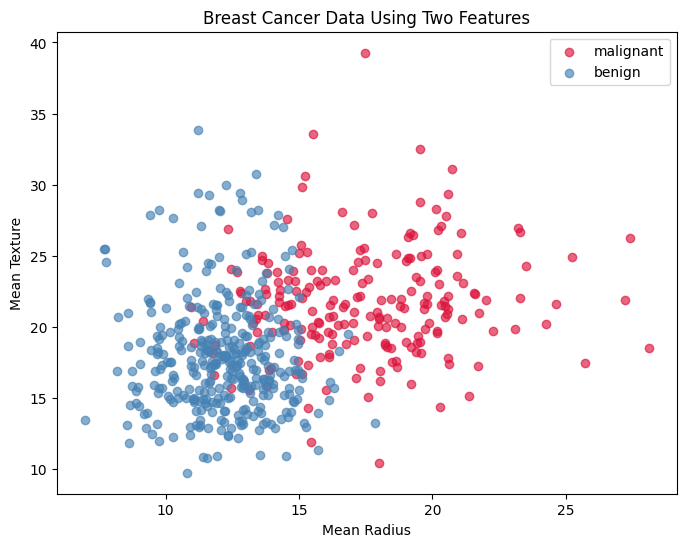

In [3]:
# Visualize the two selected features
plt.figure(figsize=(8, 6))

for label, name, color in zip(
    [0, 1],
    data.target_names,
    ["crimson", "steelblue"]
):
    plt.scatter(
        X_two[y == label, 0],
        X_two[y == label, 1],
        label=name,
        color=color,
        alpha=0.65
    )

plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.title("Breast Cancer Data Using Two Features")
plt.legend()
plt.show()

In [ ]:
## Prediction Before Training

I expect both coefficients to be negative because larger values of `mean radius` and `mean texture` appear to be associated with the
malignant class, which is class 0.

I expect the two-feature model to have lower test accuracy than the 30-feature model because it uses less information. However, more 
features do not always guarantee better performance.

In [5]:
# Step 2: Split and scale the two-feature dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X_two,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

# Learn scaling statistics only from the training set
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the two-feature Logistic Regression model
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_pred)

print("Coefficient shape:", model.coef_.shape)

for feature, coefficient in zip(
    selected_features,
    model.coef_[0]
):
    print(f"{feature}: {coefficient:.4f}")

print("Intercept:", model.intercept_[0])
print("Two-feature test accuracy:", test_accuracy)

Coefficient shape: (1, 2)
mean radius: -3.2886
mean texture: -0.8304
Intercept: 0.6739346313989217
Two-feature test accuracy: 0.8771929824561403


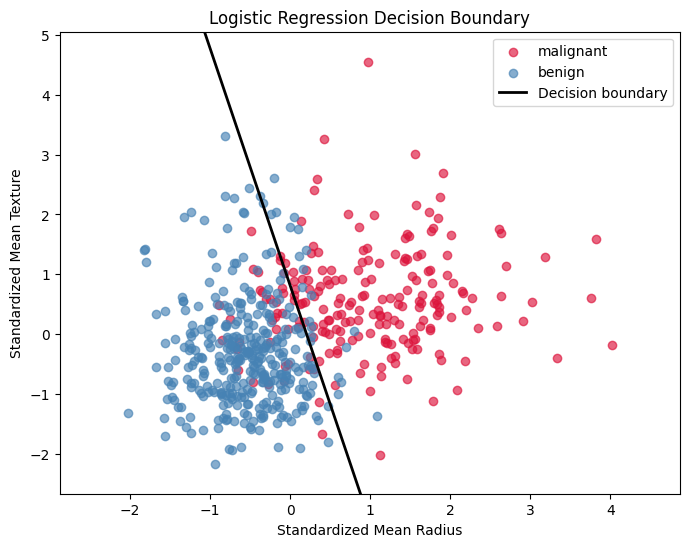

In [9]:
# Step 3: Vsualize the decision boundary

# Transform all samples using training-set scaling statistics
X_two_scaled = scaler.transform(X_two)

# Extract the learned parameters
w1, w2 = model.coef_[0]
b = model.intercept_[0]

# Create x-values and calculate the corresponding boundary y-values
x1_values = np.linspace(
    X_two_scaled[:, 0].min() - 0.5,
    X_two_scaled[:, 0].max() + 0.5,
    200
)

x2_boundary = -(w1 * x1_values + b) / w2

plt.figure(figsize=(8,6))

for label, name, color in zip(
    [0, 1],
    data.target_names,
    ["crimson", "steelblue"]
):
    plt.scatter(
        X_two_scaled[y == label, 0],
        X_two_scaled[y == label, 1],
        label=name,
        color=color,
        alpha=0.65
    )

plt.plot(
    x1_values,
    x2_boundary,
    color="black",
    linewidth=2,
    label="Decision boundary"
)

plt.xlabel("Standardized Mean Radius")
plt.ylabel("Standardized Mean Texture")
plt.title("Logistic Regression Decision Boundary")
plt.legend()
plt.ylim(
    X_two_scaled[:, 1].min() - 0.5,
    X_two_scaled[:, 1].max() + 0.5
)
plt.show()

In [12]:
# Step 4: Understand Log Loss
probabilities = np.array([0.9, 0.6, 0.1])
 
# These examples all truly belong to class 1
losses = -np.log(probabilities)

for probability, loss in zip(probabilities, losses):
    print(
        f"Probability of the true class: {probability:.1f},"
        f"Log Loss: {loss:.4f}"
    )

Probability of the true class: 0.9,Log Loss: 0.1054
Probability of the true class: 0.6,Log Loss: 0.5108
Probability of the true class: 0.1,Log Loss: 2.3026


In [ ]:
# Reflection

## 1. What did I learn today?

I learned how coefficients and the intercept determine the predictions of Logistic Regression. I also visualized a decision boundary using 
`mean radius` and `mean texture`.

## 2. What surprised me?

I was surprised that Logistic Regression learns its coefficients and intercept by minimizing Log Loss rather than directly maximizing 
accuracy.

## 3. What mistakes did I make?

I initially assumed that using more features would always produce better performance. More features can provide useful information, but 
they may also introduce noise, redundancy, and overfitting.

## 4. Explain a decision boundary in my own words.

A decision boundary separates the feature space into regions predicted as different classes. With the default threshold of 0.5, points 
on the boundary have a predicted probability of 0.5.

For a two-feature Logistic Regression model, the boundary is a straight line.

## 5. Explain how coefficients affect probability.

The coefficients determine how each feature changes the linear score, z.

A positive coefficient means that increasing the feature increases z and the probability of class 1. A negative coefficient means that 
increasing the feature decreases z and the probability of class 1.

## 6. Why does Logistic Regression use Log Loss?

Accuracy only considers whether the final class prediction is correct. It does not measure how confident the model is and is difficult to 
optimize directly.

Log Loss uses predicted probabilities and strongly penalizes confident but incorrect predictions. This allows the model to gradually 
improve its coefficients during training.

## 7. Result Interpretation

The coefficient for `mean radius` was -3.2886, and the coefficient for `mean texture` was -0.8304.

Both coefficients were negative because larger values were associated with malignant, which is class 0. Increasing these features therefore 
reduced the predicted probability of benign, which is class 1.

The two-feature model achieved lower accuracy because it used less information. In this experiment, the additional features in the 
30-feature model provided useful predictive information.

The straight boundary could not classify every sample correctly because the two classes overlapped and were not linearly separable using 
these two features.